In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

import statsmodels.formula.api as smf
from statsmodels.graphics.regressionplots import influence_plot

# Step 1 - Define the problem

- Task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.

# Step 2 - Collect and Prepare Data(EDA)

## Step 2.1 - Understand the Dataset                                                      

### Step 2.1.1 Use .head(), .tail(), .info(), and .shape() to get a feel for it.    

In [8]:
toyota_df=pd.read_csv('ToyotaCorolla - MLR.csv')

In [10]:
toyota_df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [12]:
toyota_df.shape


(1436, 11)

In [14]:
toyota_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


### Step 2.1.2 check the distinct values in each column                   

In [17]:
toyota_df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [19]:
- Mean avlue of KM feature is 68533.259749 but max value is very large compare to mean, so here we can expect some outliers
- Mean avlue of CC feature is 1576.85585 but max value is very large compare to mean, so here we can expect some outliers

SyntaxError: invalid syntax (3964717389.py, line 1)

In [21]:
toyota_df['Cylinders'].value_counts()

Cylinders
4    1436
Name: count, dtype: int64

- we have only 4 Cylinders vehicles. As this we have all data with same Cylinders, this colmn is not carrying any important information.
- so we can drop this column

In [24]:
toyota_df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64

In [26]:
toyota_df['Gears'].value_counts()

Gears
5    1390
6      43
3       2
4       1
Name: count, dtype: int64

- Majorly we have 5 Gears vehicles

### Step 2.1.3 Check data types: numerical, categorical, datetime,remove unwanted columns and rows, remove duplicate rows, convert the datatype etc.

In [30]:
toyota_df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

##  Step 2.3 - Analyze Target Variable 

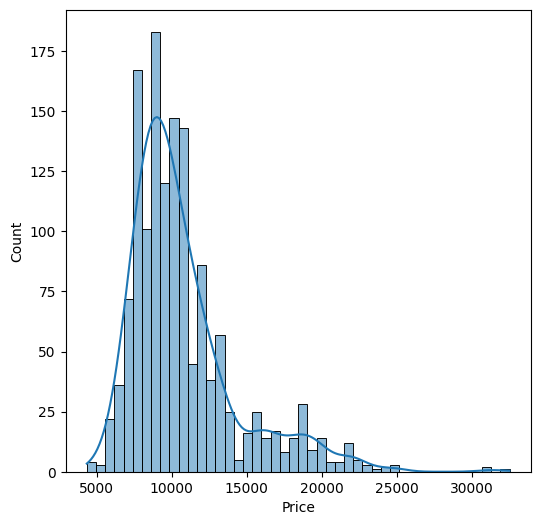

In [33]:
plt.figure(figsize=(6,6))
sns.histplot(x=toyota_df['Price'],kde=True)
plt.show()

- The distribution of target variable is right skew
- Right skew (positive skew) → common in prices, income → may need log transformation.
- As target variable rightly skewed(if we have normal distribution then only regression models), use of regression model is n ot reccomonded, as it considers residuals are normally distributed
- Rather Use tree-based models (Random Forest, Gradient Boosting, XGBoost, LightGBM)

## Step 2.4 - Univariate Analysis (Single Variable) 

- As this model has multiple x features, so we can not go for unvariate analysis

## Step 2.3 – Encoding the values

In [39]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

- OHE by using get dummies

In [42]:
pd.get_dummies(toyota_df)

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,False,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,False,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,False,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,False,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,86,0,1300,3,4,5,1025,False,False,True
1432,10845,72,19000,86,0,1300,3,4,5,1015,False,False,True
1433,8500,71,17016,86,0,1300,3,4,5,1015,False,False,True
1434,7250,70,16916,86,0,1300,3,4,5,1015,False,False,True


In [44]:
pd.get_dummies(toyota_df,dtype=int) # dtype=int - it returns the output in int

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,0,1,0
1,13750,23,72937,90,0,2000,3,4,5,1165,0,1,0
2,13950,24,41711,90,0,2000,3,4,5,1165,0,1,0
3,14950,26,48000,90,0,2000,3,4,5,1165,0,1,0
4,13750,30,38500,90,0,2000,3,4,5,1170,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,86,0,1300,3,4,5,1025,0,0,1
1432,10845,72,19000,86,0,1300,3,4,5,1015,0,0,1
1433,8500,71,17016,86,0,1300,3,4,5,1015,0,0,1
1434,7250,70,16916,86,0,1300,3,4,5,1015,0,0,1


In [46]:
toyota_df_enc=pd.get_dummies(toyota_df,dtype=int)

In [48]:
type(toyota_df_enc)

pandas.core.frame.DataFrame

In [50]:
toyota_df_enc.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,0,1,0
1,13750,23,72937,90,0,2000,3,4,5,1165,0,1,0
2,13950,24,41711,90,0,2000,3,4,5,1165,0,1,0
3,14950,26,48000,90,0,2000,3,4,5,1165,0,1,0
4,13750,30,38500,90,0,2000,3,4,5,1170,0,1,0


##  Step 2.5 - Bivariate/Multivariate Analysis

In [53]:
toyota_df_corr=toyota_df_enc.corr()
print(toyota_df_corr)

                     Price  Age_08_04        KM        HP  Automatic  \
Price             1.000000  -0.876590 -0.569960  0.314990   0.033081   
Age_08_04        -0.876590   1.000000  0.505672 -0.156622   0.031717   
KM               -0.569960   0.505672  1.000000 -0.333538  -0.081854   
HP                0.314990  -0.156622 -0.333538  1.000000   0.013144   
Automatic         0.033081   0.031717 -0.081854  0.013144   1.000000   
cc                0.126389  -0.098084  0.102683  0.035856   0.066740   
Doors             0.185326  -0.148359 -0.036197  0.092424  -0.027654   
Cylinders              NaN        NaN       NaN       NaN        NaN   
Gears             0.063104  -0.005364  0.015023  0.209477  -0.098555   
Weight            0.581198  -0.470253 -0.028598  0.089614   0.057249   
Fuel_Type_CNG    -0.039536   0.002389  0.144016  0.062109   0.001486   
Fuel_Type_Diesel  0.054084  -0.097740  0.403060 -0.533453  -0.084490   
Fuel_Type_Petrol -0.038516   0.092611 -0.433160  0.489110   0.08

In [55]:
toyota_df_corr=toyota_df_enc.corr().round(2)
print(toyota_df_corr)
#sns.heatmap(toyota_df_corr)

                  Price  Age_08_04    KM    HP  Automatic    cc  Doors  \
Price              1.00      -0.88 -0.57  0.31       0.03  0.13   0.19   
Age_08_04         -0.88       1.00  0.51 -0.16       0.03 -0.10  -0.15   
KM                -0.57       0.51  1.00 -0.33      -0.08  0.10  -0.04   
HP                 0.31      -0.16 -0.33  1.00       0.01  0.04   0.09   
Automatic          0.03       0.03 -0.08  0.01       1.00  0.07  -0.03   
cc                 0.13      -0.10  0.10  0.04       0.07  1.00   0.08   
Doors              0.19      -0.15 -0.04  0.09      -0.03  0.08   1.00   
Cylinders           NaN        NaN   NaN   NaN        NaN   NaN    NaN   
Gears              0.06      -0.01  0.02  0.21      -0.10  0.01  -0.16   
Weight             0.58      -0.47 -0.03  0.09       0.06  0.34   0.30   
Fuel_Type_CNG     -0.04       0.00  0.14  0.06       0.00  0.01   0.01   
Fuel_Type_Diesel   0.05      -0.10  0.40 -0.53      -0.08  0.33   0.03   
Fuel_Type_Petrol  -0.04       0.09 -0.

In [56]:
display(toyota_df_corr)

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
Price,1.00,-0.88,-0.57,0.31,0.03,0.13,0.19,NaN,0.06,0.58,-0.04,0.05,-0.04
Age_08_04,-0.88,1.00,0.51,-0.16,0.03,-0.10,-0.15,NaN,-0.01,-0.47,0.00,-0.10,0.09
KM,-0.57,0.51,1.00,-0.33,-0.08,0.10,-0.04,NaN,0.02,-0.03,0.14,0.40,-0.43
HP,0.31,-0.16,-0.33,1.00,0.01,0.04,0.09,NaN,0.21,0.09,0.06,-0.53,0.49
Automatic,0.03,0.03,-0.08,0.01,1.00,0.07,-0.03,NaN,-0.10,0.06,0.00,-0.08,0.08
cc,0.13,-0.10,0.10,0.04,0.07,1.00,0.08,NaN,0.01,0.34,0.01,0.33,-0.32
Doors,0.19,-0.15,-0.04,0.09,-0.03,0.08,1.00,NaN,-0.16,0.30,0.01,0.03,-0.03
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gears,0.06,-0.01,0.02,0.21,-0.10,0.01,-0.16,NaN,1.00,0.02,-0.05,-0.05,0.06
Weight,0.58,-0.47,-0.03,0.09,0.06,0.34,0.30,NaN,0.02,1.00,0.05,0.57,-0.56


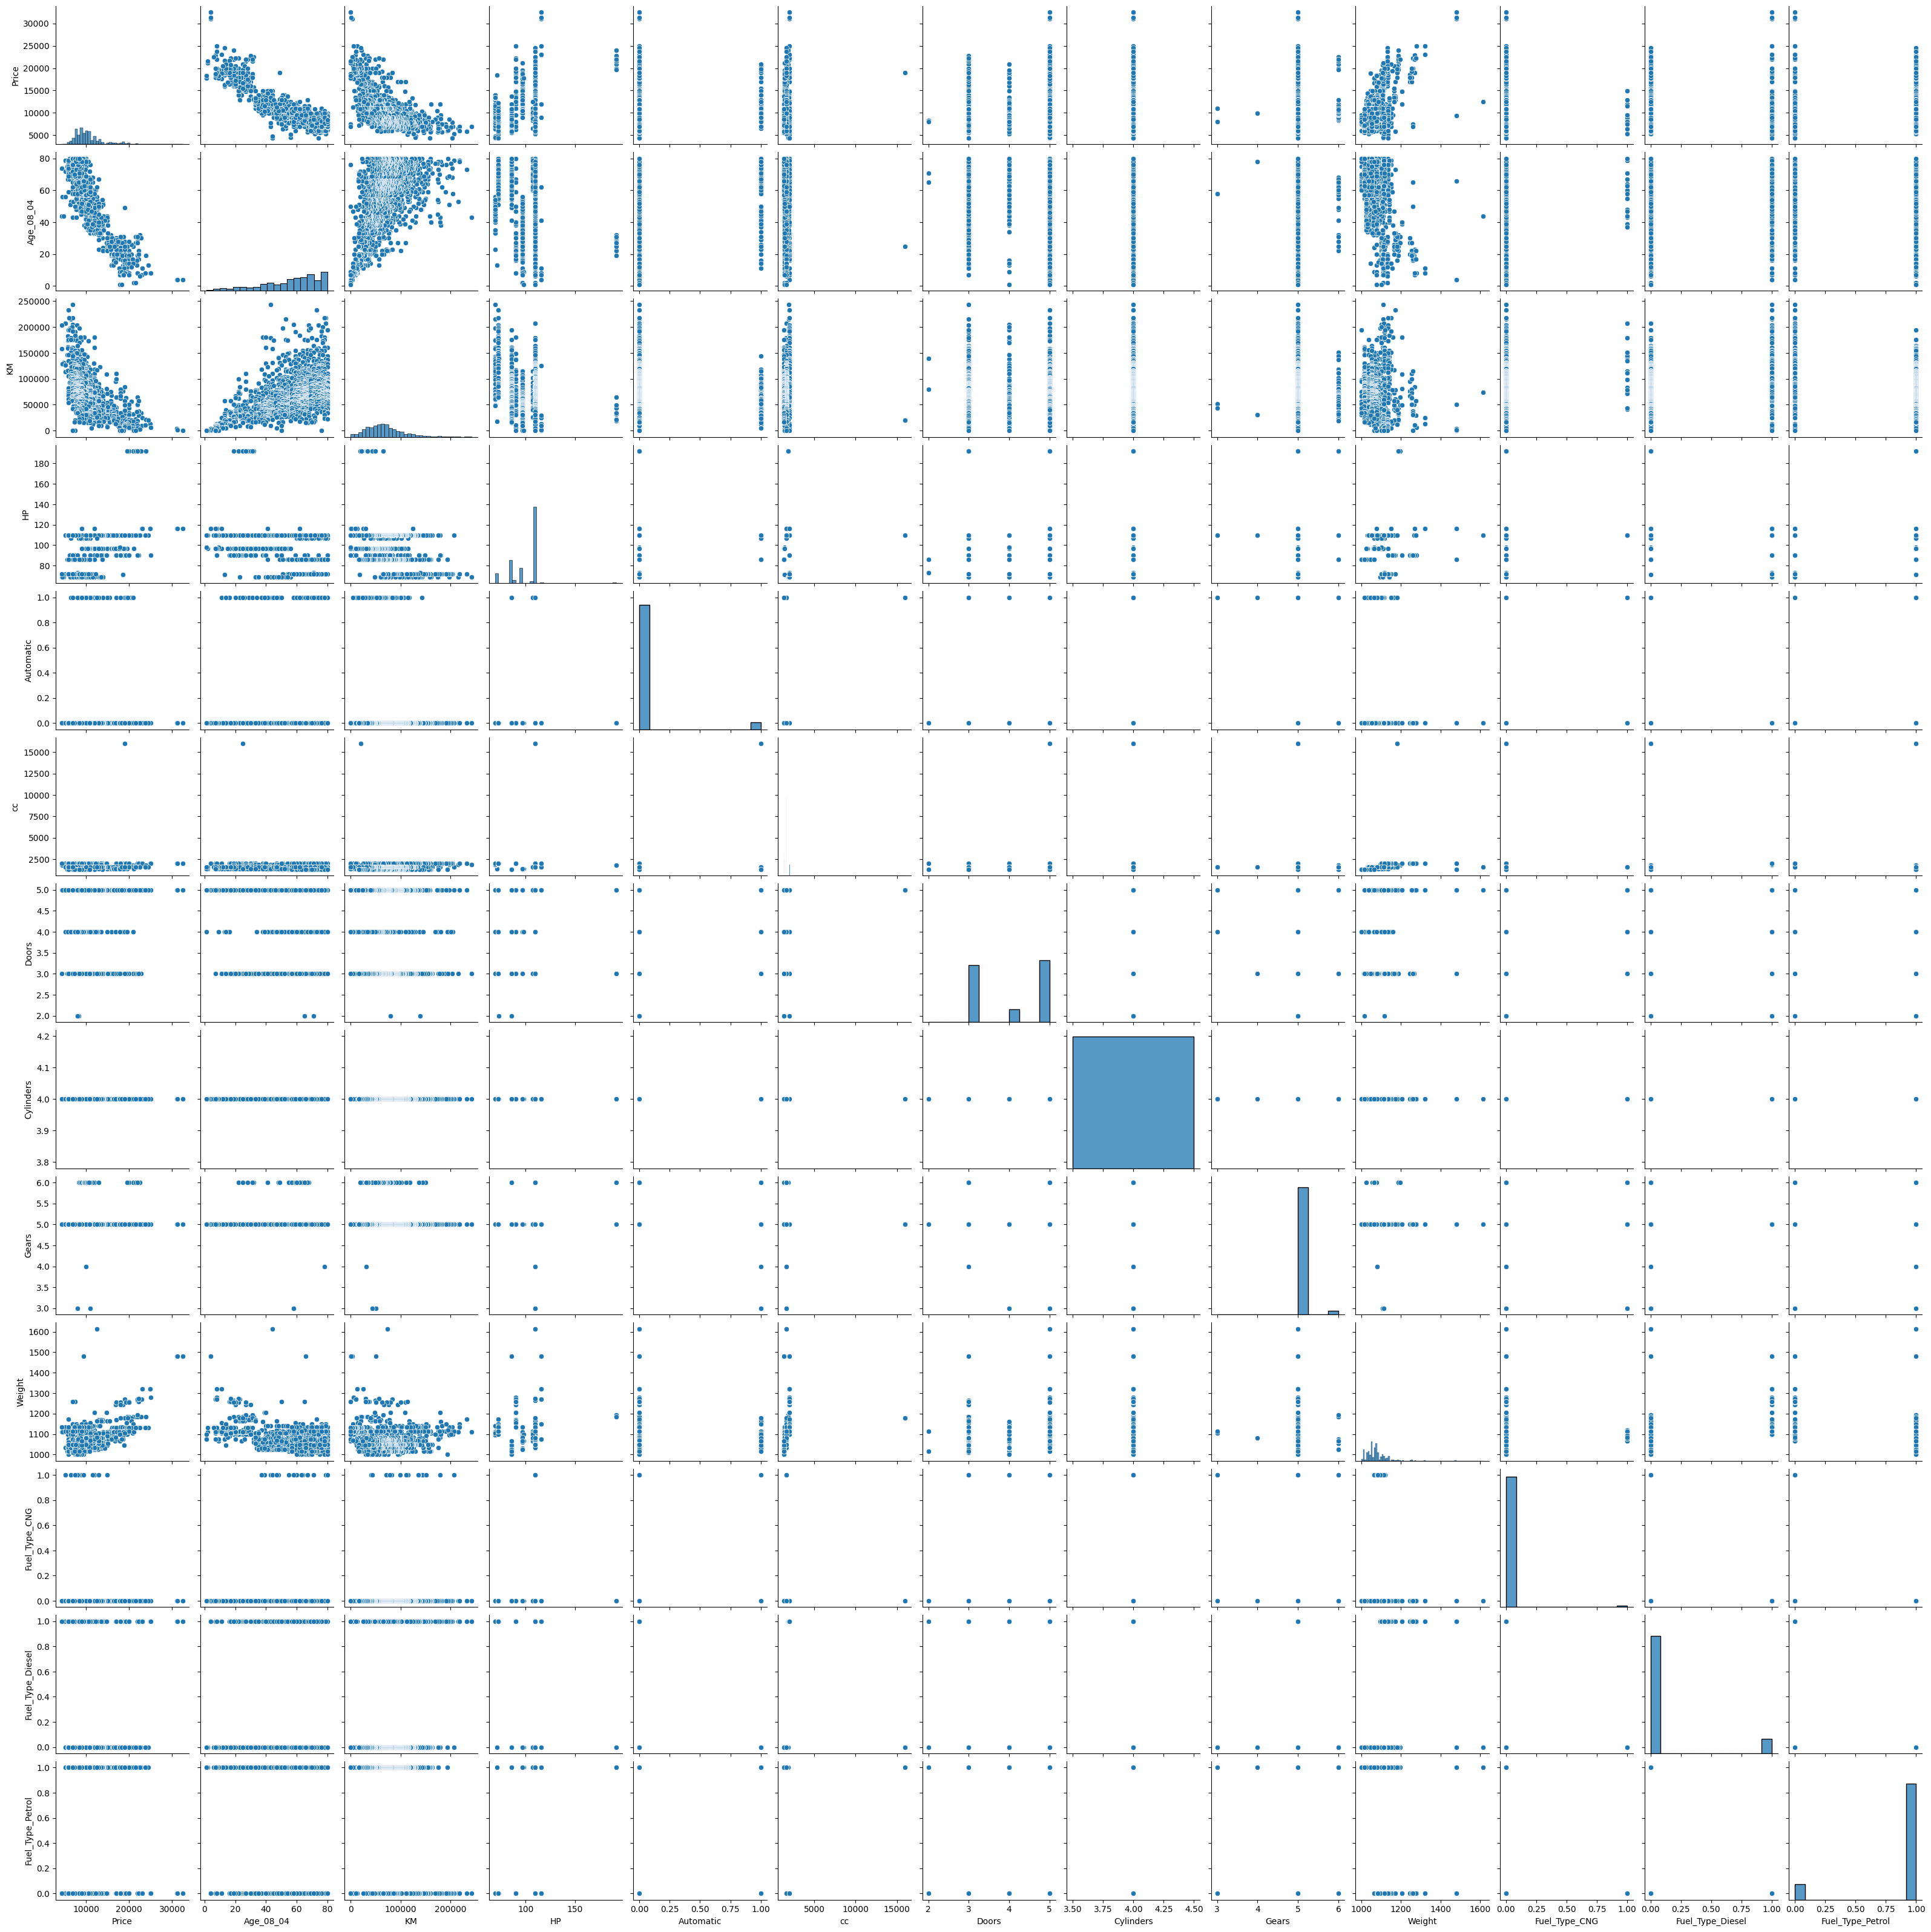

In [58]:
sns.pairplot(toyota_df_enc)
plt.show()

- Correlation with Y
- - By looking at the above graph we can say that price is negatively corelated with age
- - By looking at the above graph we can say that price is negatively corelated with KM
 
- Correlation within X features
- - Fuel_type_Diesel is higluy corelated with  Fuel_type_petrol(so we need to drop any of the column)

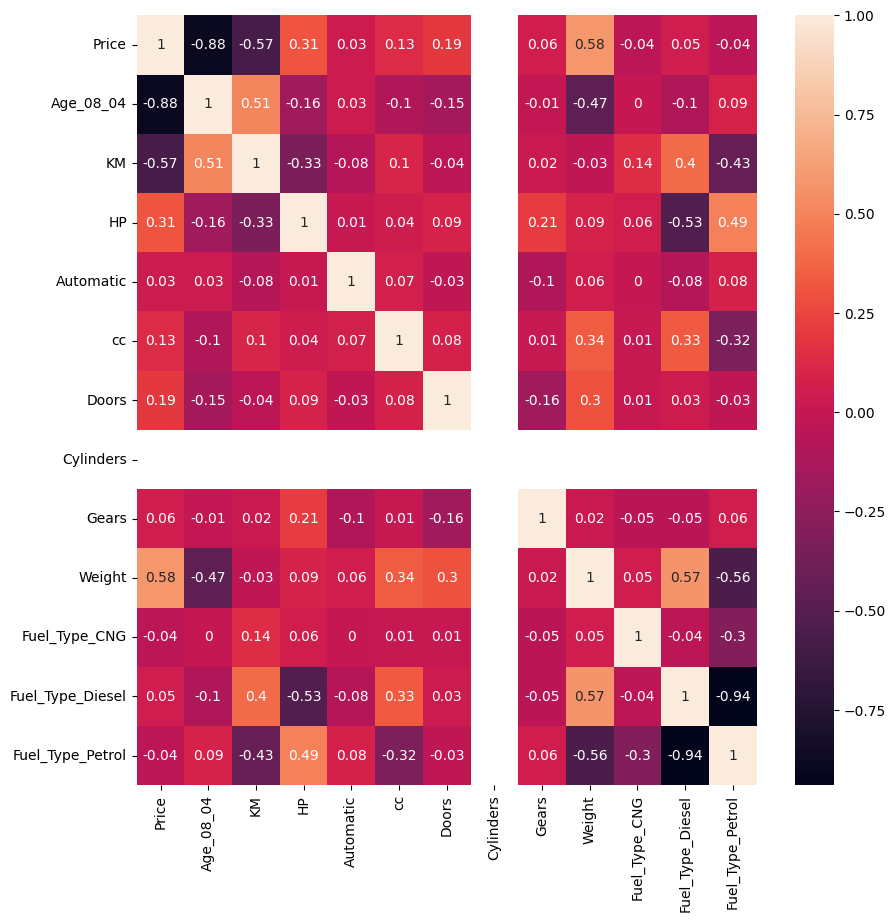

In [62]:
plt.figure(figsize=(10,10))
sns.heatmap(toyota_df_corr,annot=True)
plt.show()

- BY looking at the heatmp we can say that only AGe and KM feature mainly contributing to price

##  Step 2.11 - Outlier Detection

###  Step 2.11 - Outlier Detection for Age

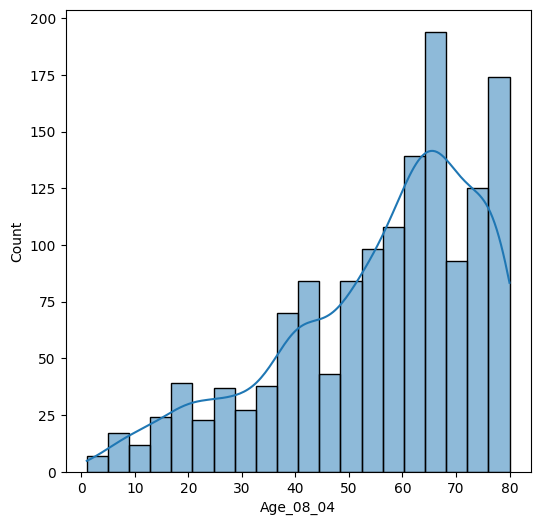

In [67]:
plt.figure(figsize=(6,6))
sns.histplot(toyota_df_enc,x='Age_08_04',bins=20,kde=True)
plt.show()

<Figure size 300x300 with 0 Axes>

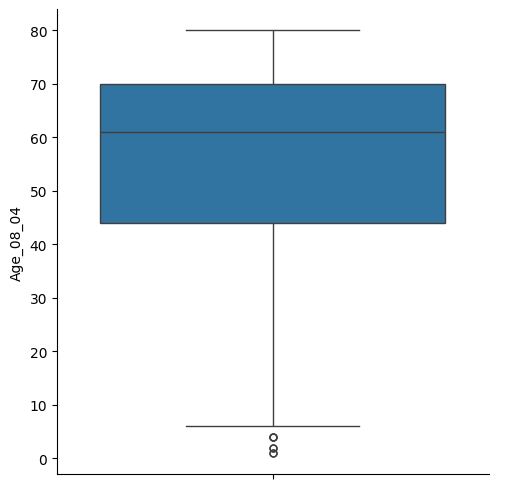

In [68]:
plt.figure(figsize=(3,3))
sns.catplot(toyota_df_enc,y='Age_08_04',kind='box')
plt.show()

In [70]:
Age_08_04_q1=toyota_df_enc['Age_08_04'].quantile(0.25)
Age_08_04_q3=toyota_df_enc['Age_08_04'].quantile(0.75)
print(Age_08_04_q1,Age_08_04_q3)

44.0 70.0


In [72]:
IQR = Age_08_04_q3-Age_08_04_q1
print(IQR)

26.0


In [75]:
Age_08_04_lower_limit=Age_08_04_q1-1.5*IQR
Age_08_04_upper_limit=Age_08_04_q3+1.5*IQR
print(Age_08_04_lower_limit,Age_08_04_upper_limit)

5.0 109.0


In [77]:
toyota_df_enc['Age_08_04'][(toyota_df_enc['Age_08_04'] > Age_08_04_upper_limit) | (toyota_df_enc['Age_08_04'] < Age_08_04_lower_limit)]

109    4
110    4
111    4
182    2
183    2
184    1
185    1
Name: Age_08_04, dtype: int64

In [79]:
def plot_box_plot(dataframe,feature):
    plt.figure(figsize=(2,2))
    sns.catplot(dataframe,y=feature,kind='box')
    plt.show()
    


<Figure size 200x200 with 0 Axes>

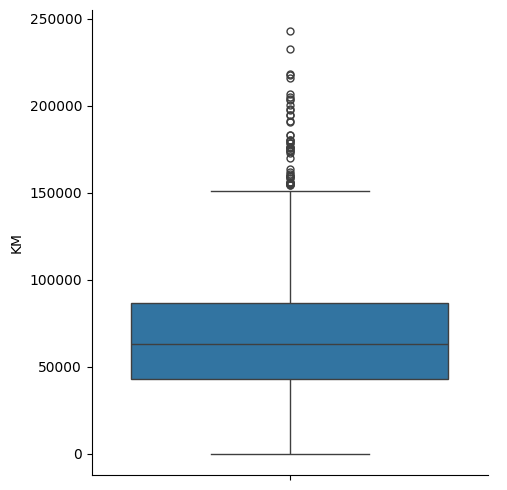

In [81]:
plot_box_plot(toyota_df_enc,'KM')

In [83]:
toyota_df_enc.select_dtypes(include=['number'])

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,0,1,0
1,13750,23,72937,90,0,2000,3,4,5,1165,0,1,0
2,13950,24,41711,90,0,2000,3,4,5,1165,0,1,0
3,14950,26,48000,90,0,2000,3,4,5,1165,0,1,0
4,13750,30,38500,90,0,2000,3,4,5,1170,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,86,0,1300,3,4,5,1025,0,0,1
1432,10845,72,19000,86,0,1300,3,4,5,1015,0,0,1
1433,8500,71,17016,86,0,1300,3,4,5,1015,0,0,1
1434,7250,70,16916,86,0,1300,3,4,5,1015,0,0,1


In [85]:
toyota_df_enc.select_dtypes(include=['number']).columns.to_list()

['Price',
 'Age_08_04',
 'KM',
 'HP',
 'Automatic',
 'cc',
 'Doors',
 'Cylinders',
 'Gears',
 'Weight',
 'Fuel_Type_CNG',
 'Fuel_Type_Diesel',
 'Fuel_Type_Petrol']

<Figure size 200x200 with 0 Axes>

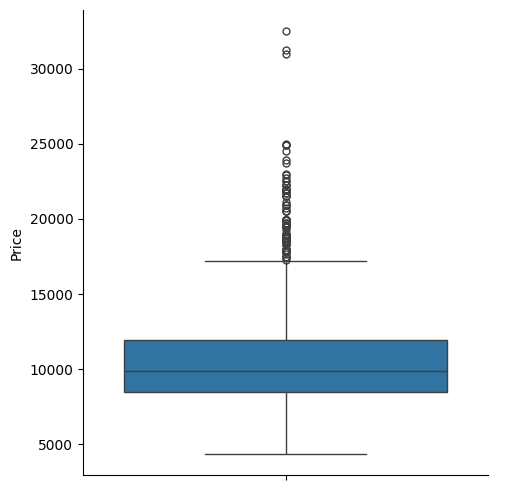

<Figure size 200x200 with 0 Axes>

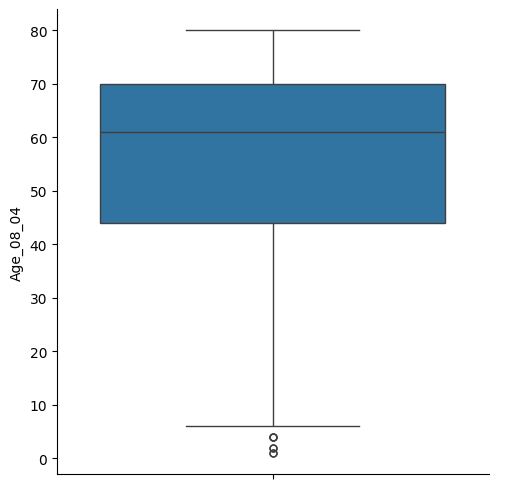

<Figure size 200x200 with 0 Axes>

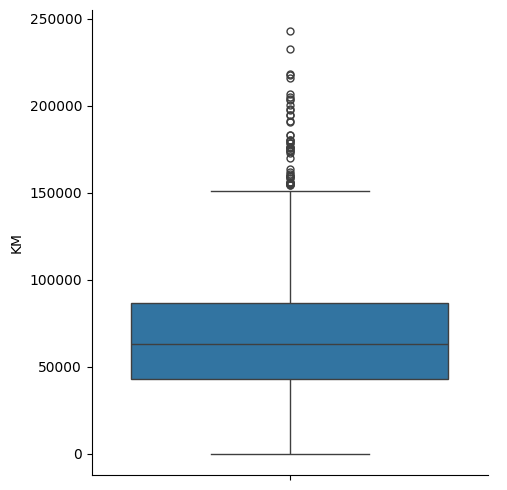

<Figure size 200x200 with 0 Axes>

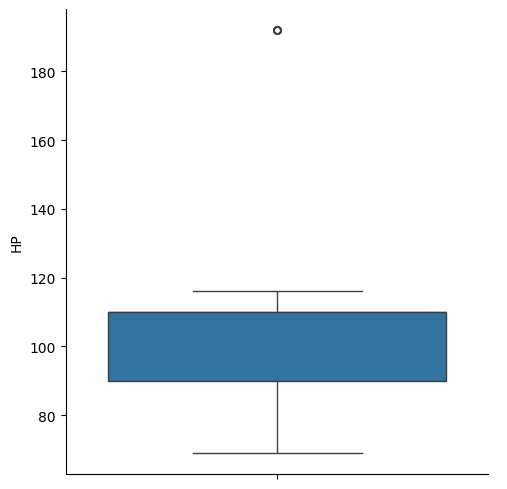

<Figure size 200x200 with 0 Axes>

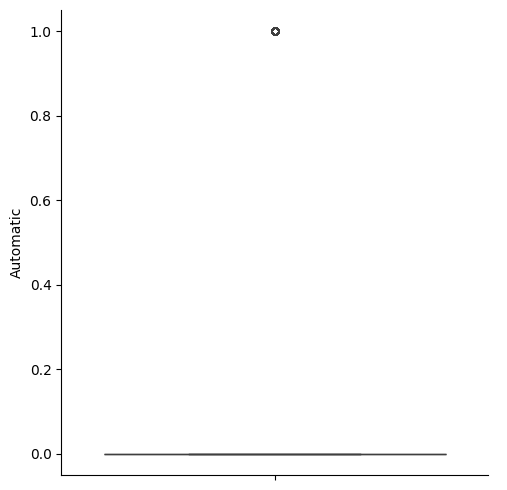

<Figure size 200x200 with 0 Axes>

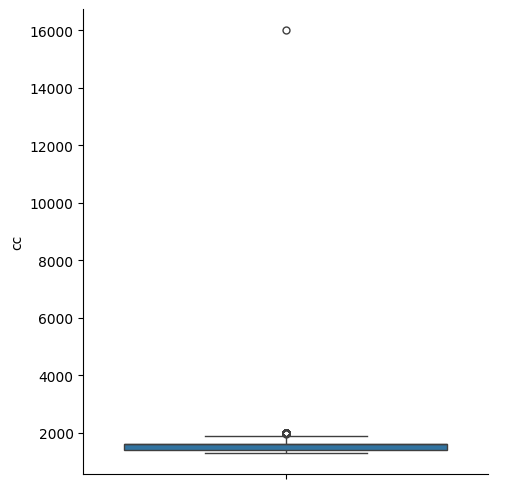

<Figure size 200x200 with 0 Axes>

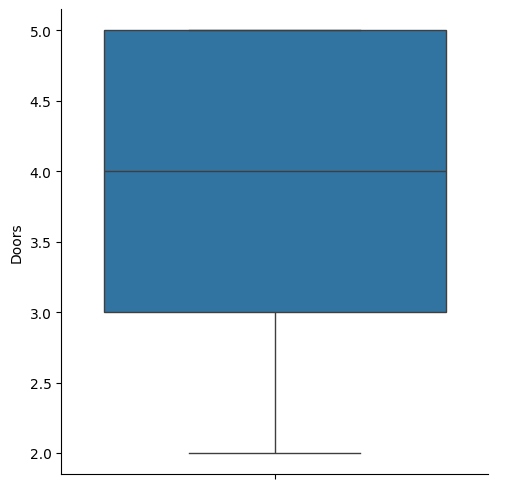

<Figure size 200x200 with 0 Axes>

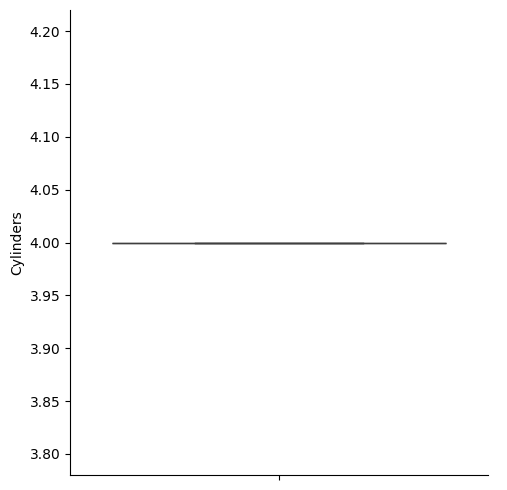

<Figure size 200x200 with 0 Axes>

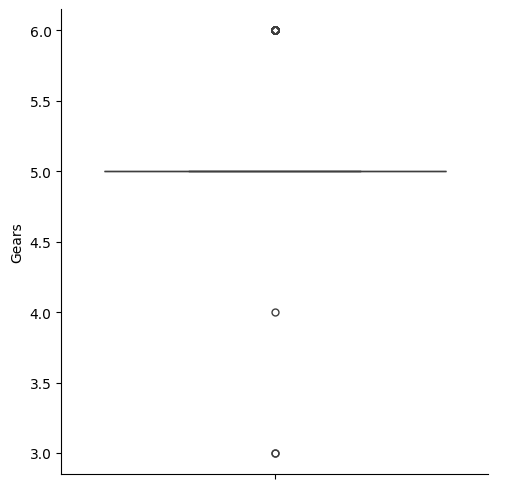

<Figure size 200x200 with 0 Axes>

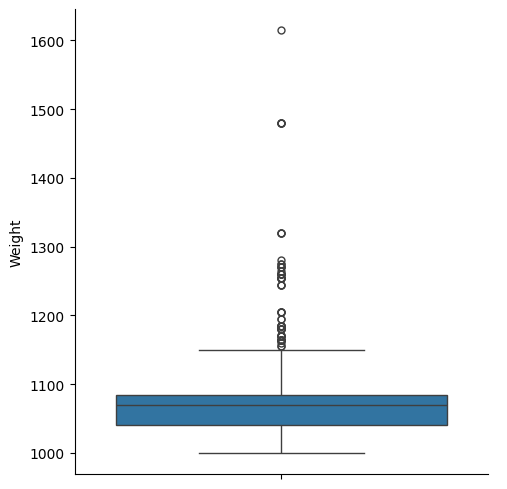

<Figure size 200x200 with 0 Axes>

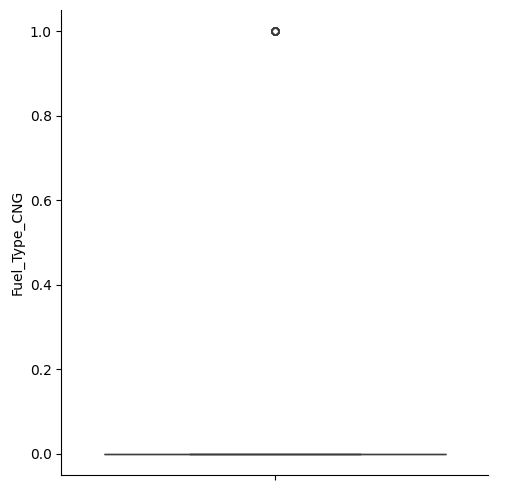

<Figure size 200x200 with 0 Axes>

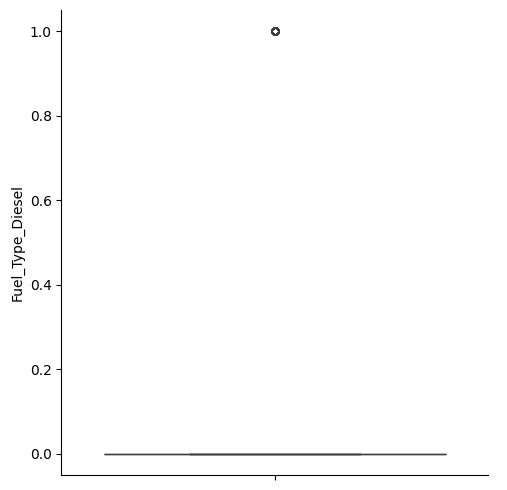

<Figure size 200x200 with 0 Axes>

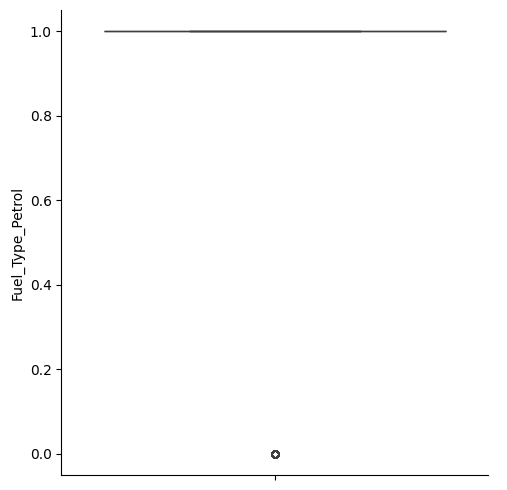

In [87]:
for i in toyota_df_enc.select_dtypes(include=['number']).columns.to_list():
    plot_box_plot(toyota_df_enc,i)
    

In [88]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        before = df_clean.shape[0]
        df_clean = df_clean[(df_clean[col] >= lower_limit) & (df_clean[col] <= upper_limit)]
        after = df_clean.shape[0]

        print(f"{col}: Q1={Q1}, Q3={Q3}, IQR={IQR}, lower={lower_limit}, upper={upper_limit}, removed={before-after}")

    return df_clean

In [89]:
toyota_df_enc_no_outlier1 = remove_outliers_iqr(toyota_df_enc, ['Price','Age_08_04','KM','HP','Weight'])

Price: Q1=8450.0, Q3=11950.0, IQR=3500.0, lower=3200.0, upper=17200.0, removed=110
Age_08_04: Q1=49.25, Q3=71.0, IQR=21.75, lower=16.625, upper=103.625, removed=6
KM: Q1=47357.5, Q3=89956.75, IQR=42599.25, lower=-16541.375, upper=153855.625, removed=49
HP: Q1=90.0, Q3=110.0, IQR=20.0, lower=60.0, upper=140.0, removed=0
Weight: Q1=1035.0, Q3=1075.0, IQR=40.0, lower=975.0, upper=1135.0, removed=39


In [90]:
toyota_df_enc_no_outlier1.shape

(1232, 13)

In [91]:
toyota_df_enc_no_outlier1.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
count,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.0,1232.000000,1232.000000,1232.000000,1232.000000,1232.00000
mean,9953.620130,59.590909,67797.336039,101.763799,0.056006,1535.555195,3.995942,4.0,5.025162,1059.279221,0.012175,0.050325,0.93750
std,2245.471412,14.786699,29146.628058,11.773184,0.230028,159.887451,0.953415,0.0,0.189531,29.773883,0.109713,0.218703,0.24216
min,4450.000000,17.000000,1.000000,69.000000,0.000000,1300.000000,2.000000,4.0,3.000000,1000.000000,0.000000,0.000000,0.00000
25%,8450.000000,50.000000,46321.250000,97.000000,0.000000,1400.000000,3.000000,4.0,5.000000,1035.000000,0.000000,0.000000,1.00000
50%,9725.000000,62.000000,64660.000000,110.000000,0.000000,1600.000000,4.000000,4.0,5.000000,1060.000000,0.000000,0.000000,1.00000
75%,10950.000000,71.000000,85247.250000,110.000000,0.000000,1600.000000,5.000000,4.0,5.000000,1075.000000,0.000000,0.000000,1.00000
max,17200.000000,80.000000,151000.000000,116.000000,1.000000,2000.000000,5.000000,4.0,6.000000,1135.000000,1.000000,1.000000,1.00000


In [92]:
toyota_df_enc_no_outlier1.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
9,12950,23,71138,69,0,1900,3,4,5,1105,0,1,0
18,16750,24,25563,110,0,1600,3,4,5,1065,0,0,1
19,16950,30,64359,110,0,1600,3,4,5,1105,0,0,1
20,15950,30,67660,110,0,1600,3,4,5,1105,0,0,1
22,15950,28,56349,110,0,1600,3,4,5,1120,0,0,1


<Figure size 200x200 with 0 Axes>

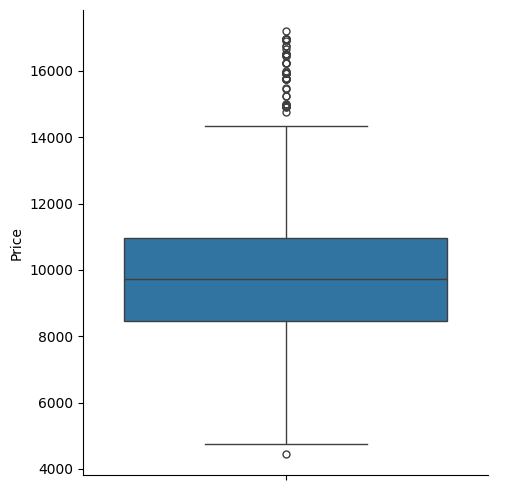

<Figure size 200x200 with 0 Axes>

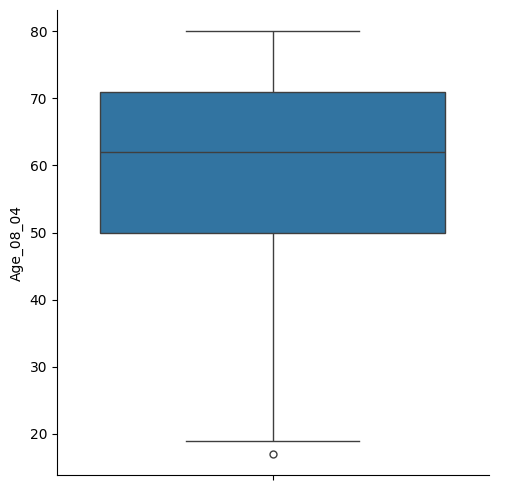

<Figure size 200x200 with 0 Axes>

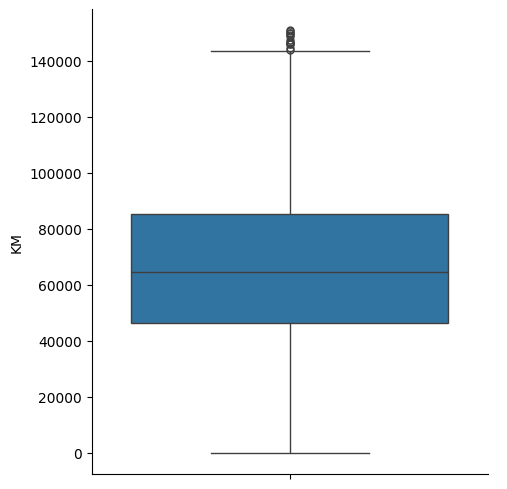

<Figure size 200x200 with 0 Axes>

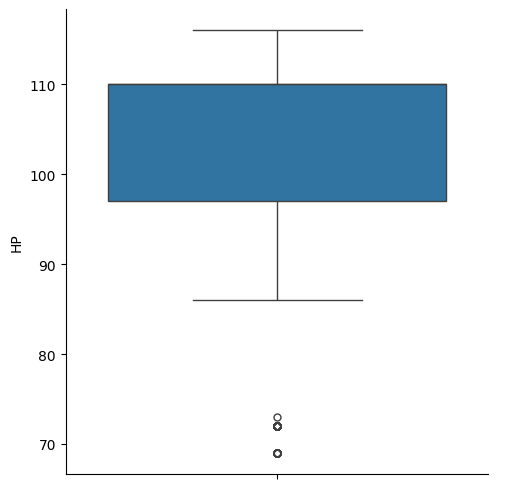

<Figure size 200x200 with 0 Axes>

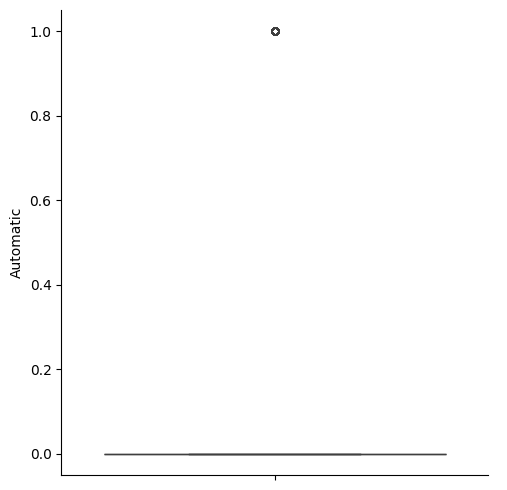

<Figure size 200x200 with 0 Axes>

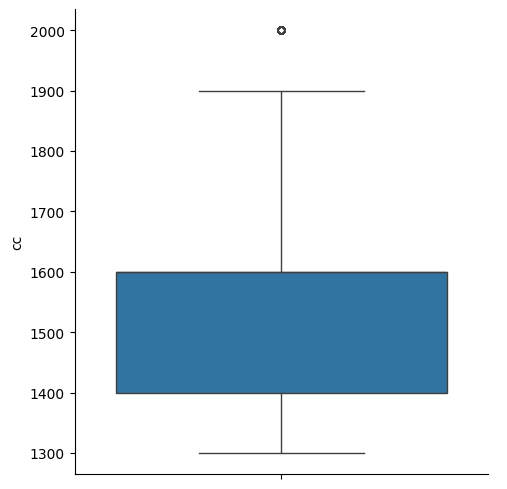

<Figure size 200x200 with 0 Axes>

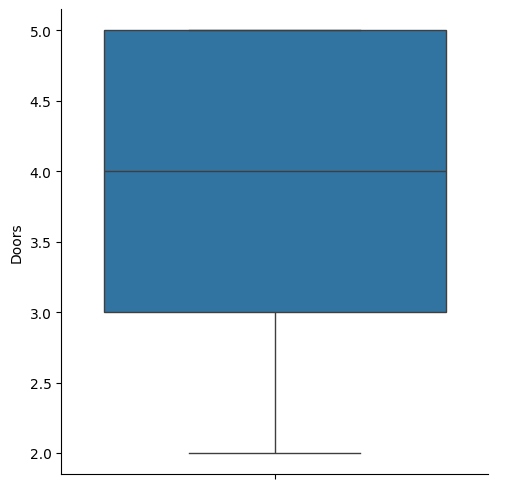

<Figure size 200x200 with 0 Axes>

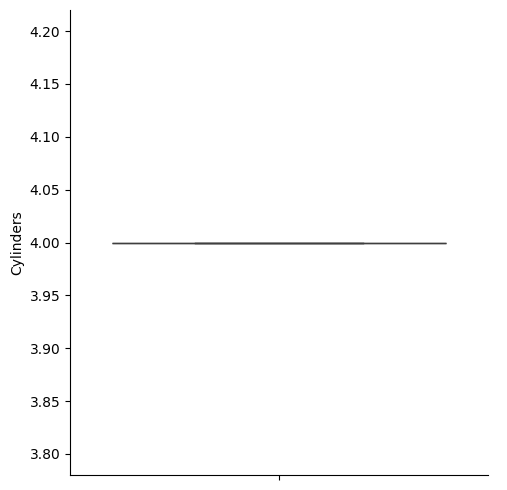

<Figure size 200x200 with 0 Axes>

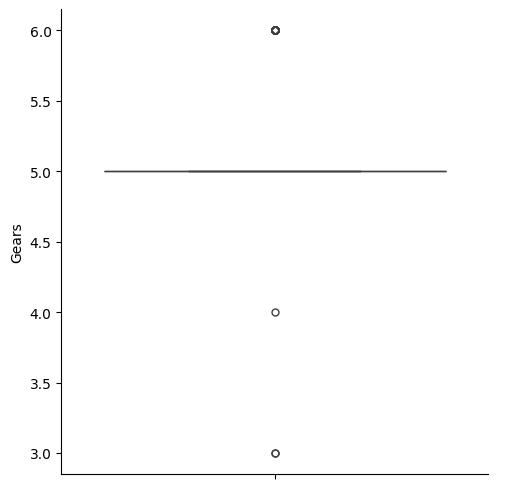

<Figure size 200x200 with 0 Axes>

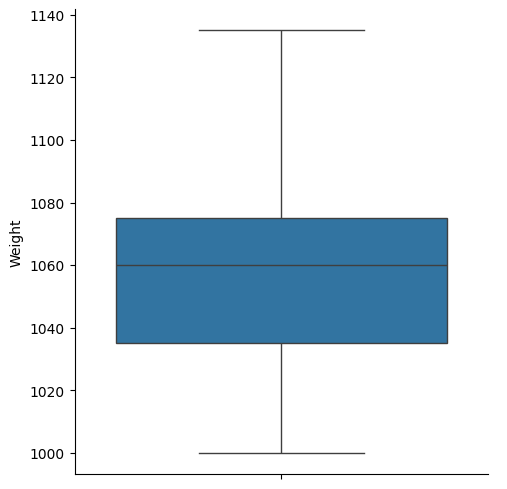

<Figure size 200x200 with 0 Axes>

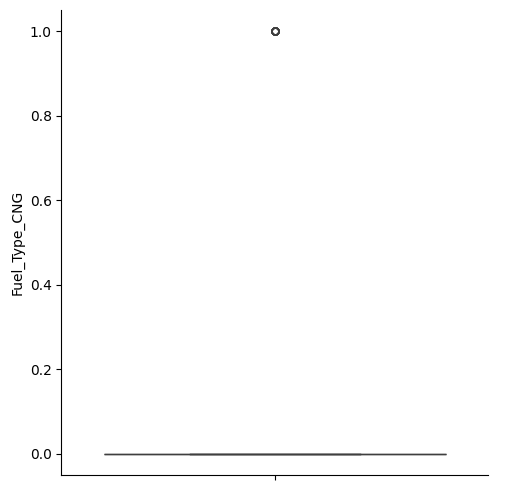

<Figure size 200x200 with 0 Axes>

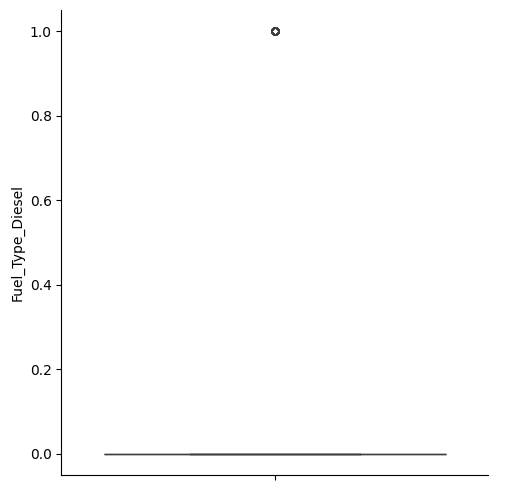

<Figure size 200x200 with 0 Axes>

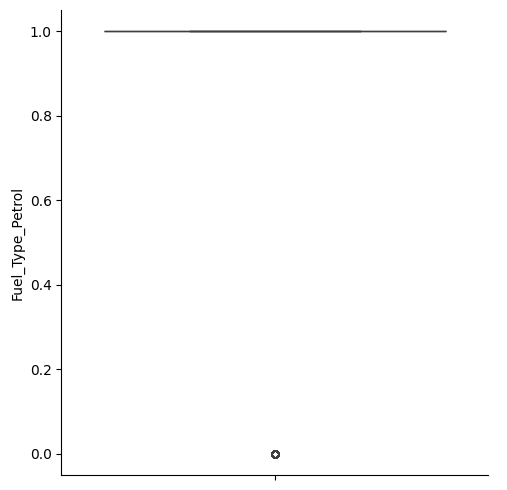

In [93]:
for i in toyota_df_enc_no_outlier1.select_dtypes(include=['number']).columns.to_list():
    plot_box_plot(toyota_df_enc_no_outlier1,i)
    #print(i)

# MODEL - 1

# Step 3 - Split the Data

##  Step 3.1 - find out independent and dependent variable

- Price the dependent feature

##  Step 3.2 split the data into X-train and Y-train

In [234]:
from sklearn.model_selection import train_test_split

In [236]:
toyota_df_enc_no_outlier1.shape

(1232, 13)

In [238]:
x=toyota_df_enc_no_outlier1.iloc[:,1:]

In [240]:
x.head()

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
9,23,71138,69,0,1900,3,4,5,1105,0,1,0
18,24,25563,110,0,1600,3,4,5,1065,0,0,1
19,30,64359,110,0,1600,3,4,5,1105,0,0,1
20,30,67660,110,0,1600,3,4,5,1105,0,0,1
22,28,56349,110,0,1600,3,4,5,1120,0,0,1


In [242]:
x.shape

(1232, 12)

In [244]:
y=toyota_df_enc_no_outlier1.iloc[:,0:1]

In [246]:
y.head()

,Price
9,12950
18,16750
19,16950
20,15950
22,15950


In [248]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [250]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((985, 12), (247, 12), (985, 1), (247, 1))

### 3.2.2 Scale the dataset – if required

In [253]:
x_train.head(3)

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
1273,75,74567,86,0,1300,3,4,5,1015,0,0,1
1102,75,123104,110,0,1600,5,4,5,1070,0,0,1
583,46,30806,97,0,1400,5,4,5,1060,0,0,1


In [255]:
from sklearn.preprocessing import StandardScaler

In [292]:
# scaling
num_col=['Age_08_04','KM','HP','Automatic','cc','Doors','Cylinders','Gears','Weight'] # need to scale only numeric and non encoded column
scaler=StandardScaler() # initialise the model

x_train_scaled = x_train.copy() # as scaler.fit_transform(x_train[num_col]) it is going writurn an array and which dont have column names
x_test_scaled = x_test.copy()

x_train_scaled[num_col]=scaler.fit_transform(x_train[num_col]) # fit on train, learns the mean and stadard deviation
x_test_scaled[num_col]=scaler.transform(x_test[num_col]) # no need to fit, it assigns the mean and standard dev learnt from x_TraIN





# Step 5 - Choose the Algorithm and Build the model

- Linear regression

# Step 6 -Train the Model

In [297]:
# model buliding
from sklearn.linear_model import LinearRegression

In [299]:
regressor=LinearRegression() # initialise the model
toyota_df_enc_model = regressor.fit(x_train_scaled,y_train)

''' pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipeline.fit(X_train, y_train) ''' # rathter doing scaling and model training seperately use pipeline

# Step 7 - Evaluate the Model

## Step 6.1 - predict the values for training data(x_train)-yhat_train

In [303]:
y_hat_train=toyota_df_enc_model.predict(x_train_scaled) # while predicting y_hat_TRain need to pass scaled data
#print(y_hat_train)

## Step 6.2 - Check the measure for x_train data and evaluate the       

In [306]:
from sklearn.metrics import mean_squared_error,r2_score

In [308]:
# toyota_df_enc_model.summary() - summary is not available in sklearn.SO we need to cehck indiviadual aparqamter


In [310]:
# Training MSE
train_mse=mean_squared_error(y_train,y_hat_train)

# Training RMSE
train_rmse=np.sqrt(train_mse)

# Training R2
train_r2=r2_score(y_train,y_hat_train)

In [312]:
print('Training mse : ', train_mse)
print('Training rmse : ',train_rmse)
print('Training r2 : ',train_r2)


Training mse :  1013742.872708167
Training rmse :  1006.8479888782452
Training r2 :  0.8018505676196115


- The r2 of model is 88% so it is not a bad model

##  Step 6.3 – Predict the output and Check the measure for x_test data and evaluate the model

In [316]:
y_hat_test=toyota_df_enc_model.predict(x_test_scaled) # while predicting y_hat_test need to pass scaled data
#print(y_hat_test)

In [318]:
## Step 6.4 - Check the measure for y_test data and evaluate the model

In [320]:
# Test MSE
test_mse=mean_squared_error(y_test,y_hat_test)

# Training RMSE
test_rmse=np.sqrt(test_mse)

# Training R2
test_r2=r2_score(y_test,y_hat_test)

In [322]:
print('test mse : ', test_mse)
print('test rmse : ',test_rmse)
print('test r2 : ',test_r2)

test mse :  1049152.5991708674
test rmse :  1024.2815038703313
test r2 :  0.7779755927526539


- As on training data model has given 80% but on the testing data it has given 77%, slighlty overfitting

In [325]:
'''from sklearn.model_selection import train_test_split
x=toyota_df_enc.iloc[:,1:]
y=toyota_df_enc.iloc[:,0:1]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

scaler=StandardScaler() 
x_train_scaled=scaler.fit_transform(x_train) 
x_test_scaled=scaler.transform(x_test)

from sklearn.linear_model import LinearRegression
regressor=LinearRegression() # initialise the model
toyota_df_enc_model = regressor.fit(x_train_scaled,y_train)

y_hat_train=toyota_df_enc_model.predict(x_train_scaled) 

train_mse=mean_squared_error(y_train,y_hat_train)
train_rmse=np.sqrt(train_mse)
train_r2=r2_score(y_train,y_hat_train)

y_hat_test=toyota_df_enc_model.predict(x_test_scaled)

test_mse=mean_squared_error(y_test,y_hat_test)
test_rmse=np.sqrt(test_mse)
test_r2=r2_score(y_test,y_hat_test) '''

'from sklearn.model_selection import train_test_split\nx=toyota_df_enc.iloc[:,1:]\ny=toyota_df_enc.iloc[:,0:1]\nx_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)\n\nscaler=StandardScaler() \nx_train_scaled=scaler.fit_transform(x_train) \nx_test_scaled=scaler.transform(x_test)\n\nfrom sklearn.linear_model import LinearRegression\nregressor=LinearRegression() # initialise the model\ntoyota_df_enc_model = regressor.fit(x_train_scaled,y_train)\n\ny_hat_train=toyota_df_enc_model.predict(x_train_scaled) \n\ntrain_mse=mean_squared_error(y_train,y_hat_train)\ntrain_rmse=np.sqrt(train_mse)\ntrain_r2=r2_score(y_train,y_hat_train)\n\ny_hat_test=toyota_df_enc_model.predict(x_test_scaled)\n\ntest_mse=mean_squared_error(y_test,y_hat_test)\ntest_rmse=np.sqrt(test_mse)\ntest_r2=r2_score(y_test,y_hat_test) '

# Step 8  - VIF

In [328]:
## 8.1 VIF of 

In [330]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [332]:


# Add constant for intercept
X_const = sm.add_constant(x)

# Calculate VIF for each variable
vif = pd.DataFrame()
vif["feature"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i)
              for i in range(X_const.shape[1])]

print(vif)



             feature        VIF
0          Age_08_04   1.705273
1                 KM   1.567422
2                 HP  79.444903
3          Automatic   1.191741
4                 cc  87.117432
5              Doors   1.539564
6          Cylinders   0.000000
7              Gears   1.075337
8             Weight   3.422324
9      Fuel_Type_CNG        inf
10  Fuel_Type_Diesel        inf
11  Fuel_Type_Petrol        inf


C:\Users\Pandhari\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\Pandhari\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


- Analysis
- Age_08_04,KM,Automatic,Doors,Gears,weight all features are having value <10. So no colinearity.
- Cylinders has VIF=0, so no variation and no power to predict the output. So can ignore this feature.
- HP,CC are having VIF>10. May colilnear to each other. So rathe that concidering both features consder only one while buldint the model.

# Step 8  - Residual analysis

## Step 8.1 Residual mean should be close to zero

In [165]:
train_residuals=y_train-y_hat_train
print(train_residuals)

            Price
1273 -1577.642062
1102 -1026.477678
583  -1494.385899
1432  2173.694280
986  -1221.791263
...           ...
1248  -685.458918
1299   417.332471
1334 -1981.989879
1035  1404.111622
1330   393.210419

[985 rows x 1 columns]


In [167]:
train_residuals.mean()

Price   -1.089547e-12
dtype: float64

- The mean very close to 0, so it is satisfying one 

## Step 8.2 Residual should be normally distributed - we can use KDE plot and Q-Q plot to check normal distribution

In [171]:
import seaborn as sns

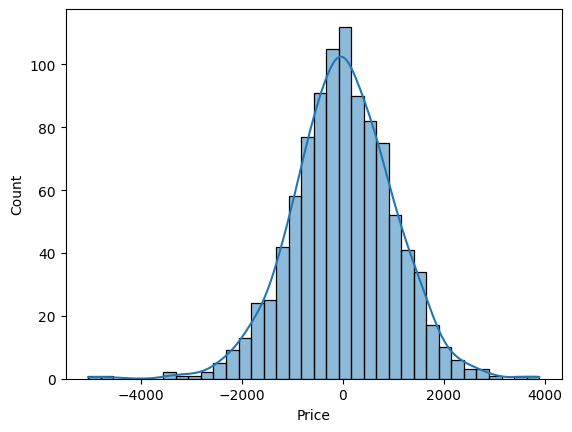

In [186]:
sns.histplot(train_residuals,x='Price', kde=True)
plt.show()

- The residuals are normally distributed

In [188]:
import statsmodels.api as sm

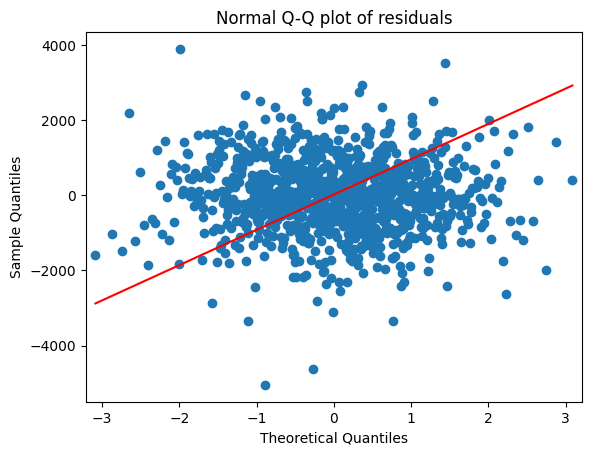

In [190]:
qqplot=sm.qqplot(train_residuals,line='q') #line=45 to draw the diagonal value
plt.title('Normal Q-Q plot of residuals')
plt.show()

## Step 8.3 Residual should have constant variance

In [193]:
def get_standerdized_values(vals):
    return (vals-vals.mean())/vals.std() # created function to get standardised value

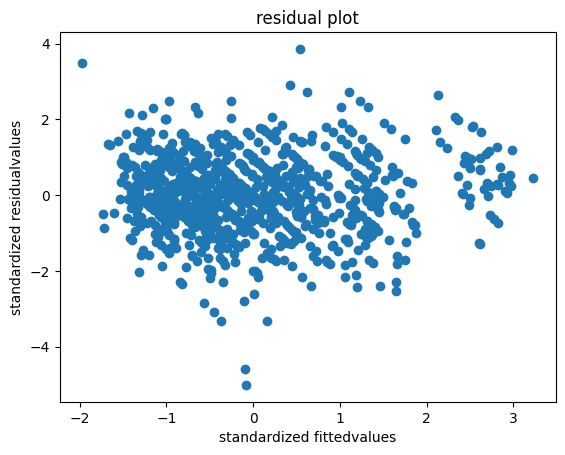

In [194]:
plt.scatter(get_standerdized_values(y_hat_train),get_standerdized_values(train_residuals))
# get_standerdized_values(y_hat_train) - always first parameter would be predicted value
# get_standerdized_values(train_residuals) - always second parameter would be predicted value
plt.title('residual plot')
plt.xlabel('standardized fittedvalues')
plt.ylabel('standardized residualvalues')
plt.show()

- By lloking at the above graph we can say that the data has constant variance(+4,-4)

# MOdel 2

- Based on the VIF result of VIF value we have considered below features model buliding

In [189]:
toyota_df_enc_no_outlier2=toyota_df_enc_no_outlier1[['Price','Age_08_04','KM','HP','Weight']]

In [191]:
toyota_df_enc_no_outlier2.head()

,Price,Age_08_04,KM,HP,Weight
9,12950,23,71138,69,1105
18,16750,24,25563,110,1065
19,16950,30,64359,110,1105
20,15950,30,67660,110,1105
22,15950,28,56349,110,1120


In [193]:
mod2_y=toyota_df_enc_no_outlier2.iloc[:,0:1]
mod2_y.head()

,Price
9,12950
18,16750
19,16950
20,15950
22,15950


In [195]:
mod2_x=toyota_df_enc_no_outlier2.iloc[:,1:]
mod2_x.head()

,Age_08_04,KM,HP,Weight
9,23,71138,69,1105
18,24,25563,110,1065
19,30,64359,110,1105
20,30,67660,110,1105
22,28,56349,110,1120


In [197]:
mod2_xtrain,mod2_xtest,mod2_ytrain,mod2_ytest=train_test_split(mod2_x,mod2_y,test_size=0.2,random_state=42)

In [199]:
mod2_xtrain.shape,mod2_xtest.shape,mod2_ytrain.shape,mod2_ytest.shape

((985, 4), (247, 4), (985, 1), (247, 1))

In [201]:
model2_scalar=StandardScaler()
model2_x_train_scaled=model2_scalar.fit_transform(mod2_xtrain)
model2_x_test_scaled=model2_scalar.transform(mod2_xtest)

In [204]:
mod_red=LinearRegression()
mod2_model=mod_red.fit(model2_x_train_scaled,mod2_ytrain)

In [206]:
mod2_yhat_train=mod2_model.predict(model2_x_train_scaled)

In [208]:
#print(mod2_yhat_train)

In [210]:
# Training MSE
mod2_train_mse=mean_squared_error(mod2_ytrain,mod2_yhat_train)

# Training RMSE
mod2_train_rmse=np.sqrt(mod2_train_mse)

# Training R2
mod2_train_r2=r2_score(mod2_ytrain,mod2_yhat_train)

In [212]:
print(mod2_train_mse)
print(mod2_train_rmse)
print(mod2_train_r2)

1070984.297371283
1034.8837120040507
0.7906619752151681


In [214]:
mod2_yhat_test=mod2_model.predict(model2_x_test_scaled)

In [216]:
# Test MSE
mod2_test_mse=mean_squared_error(mod2_ytest,mod2_yhat_test)

# Test RMSE
mod2_test_rmse=np.sqrt(mod2_test_mse)

# Test R2
mod2_test_r2=r2_score(mod2_ytest,mod2_yhat_test)

In [218]:
print(mod2_test_mse)
print(mod2_test_rmse)
print(mod2_test_r2)

1172665.9563206276
1082.8970201827262
0.7518373742227878


In [220]:
import numpy as np
model_comparison=pd.DataFrame()
model_comparison['feature']=mod2_x.columns
model_comparison['Linreg_coefficient']=np.ravel(mod2_model.coef_)
model_comparison

,feature,Linreg_coefficient
0,Age_08_04,-1598.100675
1,KM,-505.817303
2,HP,172.315919
3,Weight,374.316550


# MOdel 3 - with lasso 

In [352]:
from sklearn.linear_model import Lasso, Ridge

In [379]:
lasso_reg=Lasso(alpha=1.0)
lasso_model=lasso_reg.fit(model2_x_train_scaled,mod2_ytrain)

In [381]:
lasso_yhat_train=lasso_model.predict(model2_x_train_scaled)

In [393]:
# Training MSE
lasso_train_mse=mean_squared_error(mod2_ytrain,lasso_yhat_train)

# Training RMSE
lasso_train_rmse=np.sqrt(lasso_train_mse)

# Training R2
lasso_train_r2=r2_score(mod2_ytrain,lasso_yhat_train)

In [395]:
print(lasso_train_mse)
print(lasso_train_rmse)
print(lasso_train_r2)

1070987.0734479823
1034.8850532537333
0.7906614325943152


In [387]:

model_comparison['Lasso_coefficient']=lasso_model.coef_
model_comparison

,feature,Linreg_coefficient,Lasso_coefficient
0,Age_08_04,-1598.100675,-1597.801981
1,KM,-505.817303,-504.956518
2,HP,172.315919,171.589706
3,Weight,374.316550,373.414332


In [ ]:
# MOdel 4 - with Ridge 

In [389]:
Ridge_reg=Ridge(alpha=1.0)
Ridge_model=Ridge_reg.fit(model2_x_train_scaled,mod2_ytrain)

In [391]:
Ridge_yhat_train=Ridge_model.predict(model2_x_train_scaled)

In [397]:
# Training MSE
Ridge_train_mse=mean_squared_error(mod2_ytrain,Ridge_yhat_train)

# Training RMSE
Ridge_train_rmse=np.sqrt(mod2_train_mse)

# Training R2
Ridge_train_r2=r2_score(mod2_ytrain,lasso_yhat_train)

In [399]:
print(Ridge_train_mse)
print(Ridge_train_rmse)
print(Ridge_train_r2)

1070987.0098237856
1034.8837120040507
0.7906614325943152


In [401]:
model_comparison['Ridge_coefficient']=Ridge_model.coef_
model_comparison

,feature,Linreg_coefficient,Lasso_coefficient,Ridge_coefficient
0,Age_08_04,-1598.100675,-1597.801981,-1596.309131
1,KM,-505.817303,-504.956518,-506.135651
2,HP,172.315919,171.589706,172.165690
3,Weight,374.316550,373.414332,374.457634


# Analysis
## Model 1
### Feature selection 
- BY the method of corr and heatmap we identifies only 2 features are IMP(AGE,KM)
- Age_08_04,KM,Automatic,Doors,Gears,weight all features are having value <10. So no colinearity.
- Cylinders has VIF=0, so no variation and no power to predict the output. So can ignore this feature.
- HP,CC are having VIF>10. May colilnear to each other. So rathe that concidering both features consder only one while buldint the model.
### Residual analysis 
    mean = -3.620549e-13 - which is very close to 0
    Normal distribution - yes as per graph normally distributed
    Constant varaince - yes as per the plot it has constant variance

    As model is satisfying all the residual criteria we can say that model is performing good